Perform NicheNet analysis starting from an AnnData object: step-by-step analysis
================

In this notebook, you can learn how to perform a basic NicheNet analysis on an AnnData object containing single-cell expression data. The steps of this vignette can also be adapted for other single-cell or bulk frameworks.

Assuming you have captured the changes in gene expression resulting from your cell-cell communication (CCC) process of interest, a NicheNet analysis can help you to generate hypotheses about the CCC process. Specifically, NicheNet can predict 1) which ligands from the microenvironment or cell population(s) ("sender/niche") are most likely to affect target gene expression in an interacting cell population ("receiver/target") and 2) which specific target genes are affected by which of these predicted ligands.

To perform a NicheNet analysis, three features are extracted from the input data: the potential ligands, the gene set of interest, and the background gene set. This vignette will extract each feature as described in this flowchart:

<img src="./images/flowchart.svg" style="width:70.0%" />

As example expression data of interacting cells, we will use mouse NICHE-seq data to explore intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after lymphocytic choriomeningitis virus (LCMV) infection (Medaglia et al. 2017). We will focus on CD8 T cells as the receiver population, and as this dataset contains two conditions (before and after LCMV infection), the differentially expressed genes between these two conditions in CD8 T cells will be used as our gene set of interest. We will then prioritize which ligands from the microenvironment (sender-agnostic approach) and from specific immune cell populations like monocytes, dendritic cells, NK cells, B cells, and CD4 T cells (sender-focused approach) can regulate and induce these observed gene expression changes.

## Prepare NicheNet analysis

### Load packages

In [1]:
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import LigandReceptorNetwork, WeightedNetwork
from nichenetpy.utils import (
    read_matrix_from_csv,
    combine_by_key,
    combine_dicts
)
from nichenetpy.extraction import (
    get_expressed_genes,
    subset_ann,
    get_weighted_ligand_receptor_links,
    get_lfc_celltype
)
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.visualization import (
    prepare_ligand_target_visualization,
    prepare_ligand_receptor_visualization,
    heatmap_2d,
    heatmap_1d
)
from nichenetpy.metrics import group_metrics

from itertools import cycle, chain

import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

### Read in the expression data of interacting cells

In [2]:
# set the path to that of your local copy (this file is too large to upload to the remote git repo)
ann = anndata.io.read_h5ad("D:/Data/nichenetpy/annData/annData3531889.h5")
ann.var_names = ann.var["gene"]
ann

AnnData object with n_obs × n_vars = 5027 × 13541
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'aggregate', 'res.0.6', 'celltype'
    var: 'gene'
    layers: 'counts', 'data', 'scale.data'

Additionally, if your expression data has the older gene symbols, you may want to use our alias conversion function to avoid the loss of gene names.

In [3]:
mouse_alias_info.alias_to_symbol(ann)

Visualize which cell populations are present: CD4 T cells (including regulatory T cells), CD8 T cells, B cells, NK cells, dendritic cells (DCs) and inflammatory monocytes.

In [4]:
celltype_counts = ann.obs["celltype"].value_counts()
celltype_counts

celltype
CD4 T    2562
CD8 T    1645
B         382
Treg      199
NK        131
Mono       90
DC         18
Name: count, dtype: int64

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 13541 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


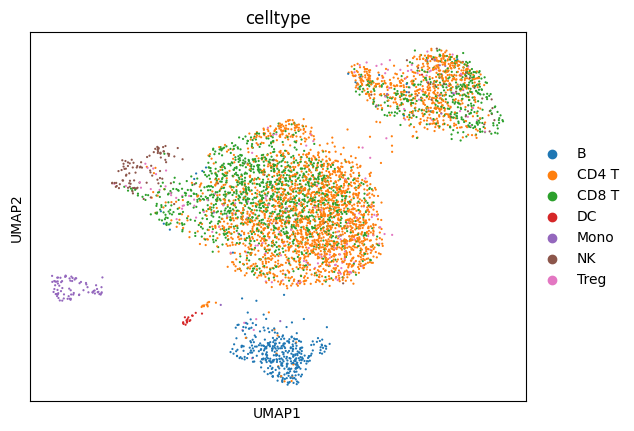

In [5]:
# need to make a copy because sc.tl.umap
# alters the AnnData object and causes an error in DotPlot
# later on, I assume this is a bug in scanpy
temp = ann.copy()
temp.X = temp.layers["data"]
sc.pp.neighbors(temp)
sc.tl.umap(temp)
sc.pl.umap(temp, gene_symbols="gene", color="celltype", size=10)

Visualize the data to see to which condition cells belong. The metadata column that denotes the condition (steady-state or after LCMV infection) is here called "aggregate".

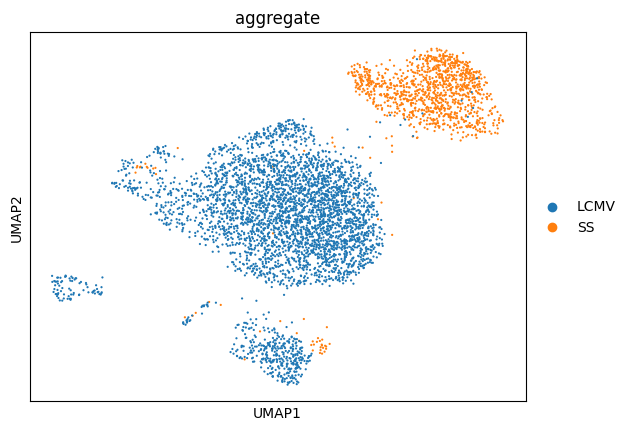

In [6]:
sc.pl.umap(temp, gene_symbols="gene", color="aggregate", size=10)

## Read in NicheNet's networks

The ligand-target prior model is a matrix describing the potential that a ligand may regulate a target gene, and it is used to run the ligand activity analysis. The ligand-receptor network contains information on potential ligand-receptor bindings, and it is used to identify potential ligands. 

In [7]:
# set the paths to that of your local copies (these files are too large to upload to the remote git repo)
predictor = LigandActivityPredictor(*read_matrix_from_csv("D:/Data/nichenetpy/model/mouse/csv/ligand_target_matrix_mouse.csv"))
lr_network = LigandReceptorNetwork(filename="D:/Data/nichenetpy/model/mouse/csv/lr_network_mouse.csv")

## Perform the NicheNet analysis

We recommend users to run both the "sender-agnostic" and "sender-focused" approach. These approaches only affect the list of potential ligands that are considered for prioritization. As described in the flowchart above, we do not define any sender populations in the ‘sender agnostic’ approach but consider all ligands for which its cognate receptor is expressed in the receiver population. The sender-focused approach will then filter the list of ligands to ones where the ligands are expressed in the sender cell population(s).

#### 1. Define a set of potential ligands for both the sender-agnostic and sender-focused approach

We first define a "receiver/target" cell population and determine which genes are expressed. Here, we will consider a gene to be expressed if it is expressed in at least 5% of cells (by default this is set to 10%). The receiver cell population can only consist of one cell type, so in case of multiple receiver populations, you will have to rerun the vignette separately for each one. We will only look at CD8 T cells in this notebook.

In [8]:
receiver = "CD8 T"
expressed_genes_receiver = set(get_expressed_genes(receiver, ann, 0.05))


Get a list of all receptors available in the ligand-receptor network, and define expressed receptors as genes that are in the ligand-receptor network and expressed in the receiver. Then, define the potential ligands as all ligands whose cognate receptors are expressed.

In [9]:
all_receptors = lr_network.get_receptors()
expressed_receptors = all_receptors.intersection(expressed_genes_receiver)
potential_ligands = set(
    key for key, group in lr_network.item_iter()
    if len(group.intersection(expressed_receptors)) > 0
)

For the sender-focused approach, define sender cell types (CD4 T, Treg, Mono, NK, B, and DC) and expressed genes in all sender populations. (Although we pool all ligands from all sender cell types together in this step, later on during the interpretation of the output, we will check which sender cell type expresses which ligand.) Then, filter potential ligands to those that are expressed in sender cells. Note that autocrine signaling can also be considered if we also include CD8 T cells as a sender.

In [10]:
sender_celltypes = ("CD4 T", "Treg", "Mono", "NK", "B", "DC")
list_expressed_genes_sender = [get_expressed_genes(ct, ann, pct=0.05) for ct in sender_celltypes]
expressed_genes_sender = set(e for l in list_expressed_genes_sender for e in l)
potential_ligands_focused = potential_ligands.intersection(expressed_genes_sender)

In [11]:
len(expressed_genes_sender)

8492

In [12]:
len(potential_ligands)

475

In [13]:
len(potential_ligands_focused)

122

#### 2. Define the gene set of interest

The gene set of interest are genes within the receiver cell type that are likely to be influenced by ligands from the CCC event. In typical case-control studies like this one, we use the differentially expressed (DE) genes between the two conditions in the receiver cell type, assuming that the observed DE pattern is a result of the CCC event (i.e., LCMV infection). The condition of interest is thus "LCMV", whereas the reference/steady-state condition is "SS". The condition can be extracted from the metadata column "aggregate". The method to calculate the differential expression is here the Wilcoxon test, but this can be changed if necessary.

In [14]:
ann_receiver = subset_ann(ann, receiver, layers=["data", "counts"]) #TODO
group_metrics(
    ann_receiver,
    groupby="aggregate",
    layer="data"
)
DE_table = ann_receiver.uns["group_metrics"]
geneset = set(DE_table[
    (DE_table["aggregate"] == "LCMV") &
    (DE_table["pval_adj"] <= 0.05) &
    (abs(DE_table["lfc"]) >= 0.25)
]["gene"])
geneset.intersection_update(predictor.get_genes())

C:\Users\victorm\Documents\nichenetpy\src\nichenetpy\wilcoxon.py:125: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (u - continuity_correction - u_mean) / u_std


In [15]:
len(geneset)

237

#### 3. Define the background genes

All expressed genes in the receiver cell population (that are also in the ligand-target matrix) is defined as the 'background set' for our ligand prioritization procedure in the next step. It's also important to check that the number of background genes is a 'reasonable' number, generally between 5000-10000, and sufficiently larger than our gene set of interest.

In [16]:
# should all be in the ligand-target matrix
len(expressed_genes_receiver)

3903

#### 4. Perform NicheNet ligand activity analysis

This is the main step of NicheNet where the potential ligands are ranked based on the presence of their target genes in the gene set of interest (compared to the background set of genes). In this case, we prioritize ligands that induce the antiviral response in CD8 T cells.

Ligands are ranked based on the area under the precision-recall curve (AUPR) between a ligand's target predictions and the observed transcriptional response. Although other metrics like the AUROC and pearson correlation coefficient are also computed, we demonstrated in our validation study that the AUPR was the most informative measure to define ligand activity. The vignette on how we performed the validation can be found at Evaluation of NicheNet’s ligand-target predictions.

We will first show the results of the sender-agnostic approach.

In [17]:
ligand_activities = predictor.predict_ligand_activities(
    geneset=geneset,
    background_expressed_genes=expressed_genes_receiver,
    potential_ligands=potential_ligands
)
ligand_activities_sorted = sorted(ligand_activities.items(), key=lambda x : x[1]["aupr_corrected"], reverse=True)

The performance metrics indicate that the 30 top-ranked ligands can predict the viral response reasonably, implying that the ranking of the ligands might be accurate. However, it is possible that for some gene sets, the target gene prediction performance of the top-ranked ligands would not be much better than random prediction. In that case, prioritization of ligands will be less trustworthy.

We will use the top 30 ligands to predict active target genes and construct an active ligand-receptor network. However, the choice of looking only at the 30 top-ranked ligands for further biological interpretation is based on biological intuition and is quite arbitrary. Therefore, users can decide to continue the analysis with a different number of ligands. We recommend to check the selected cutoff by looking at the distribution of the ligand activity values. Here, we show the ligand activity histogram (the score for the 30th ligand is indicated via the dashed line).

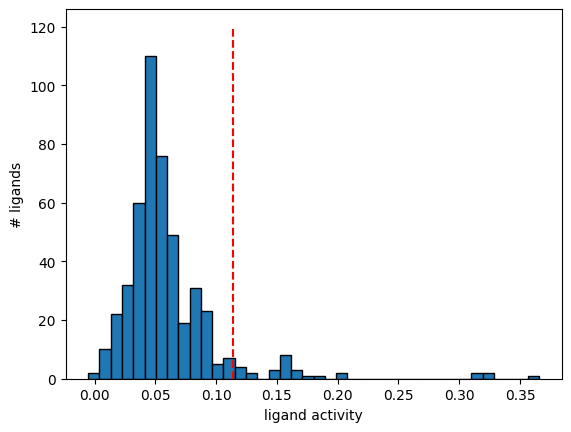

In [18]:
vals = [e[1]["aupr_corrected"] for e in ligand_activities_sorted]
plt.hist(vals, bins=40, edgecolor="black")
plt.vlines(x=vals[29], ymin=0, ymax=120, color="red", linestyles="dashed")
plt.xlabel("ligand activity")
plt.ylabel("# ligands")
plt.show()

We can also visualize the ligand activity measure (AUPR) of these top-ranked ligands:

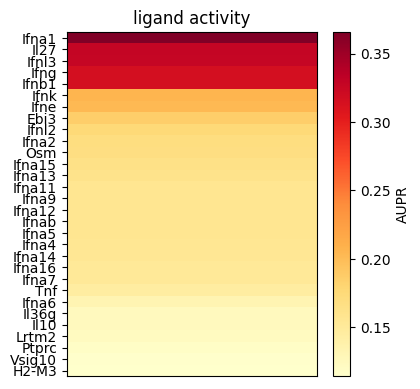

In [19]:
ligands, metrics = zip(*ligand_activities_sorted[:30])
fig, ax = heatmap_1d(
    [e["aupr_corrected"] for e in metrics],
    labels=ligands,
    title="ligand activity",
    cbar_label="AUPR",
    cmap="YlOrRd",
    figsize=(4, 4)
)
ax.invert_yaxis()
plt.show()

#### 5. Infer target genes and receptors of top-ranked ligands

Active target genes are defined as genes in the gene set of interest that have the highest regulatory potential for each top-ranked ligand. These top targets of each ligand are based on the prior model. The function get_weighted_ligand_target_links will return genes that are in the gene set of interest and are the top n targets of a ligand (default: n = 250, but there are too many target genes here so we only considered the top 100).

In [20]:
best_upstream_ligands = [e[0] for e in ligand_activities_sorted[:30]]
active_ligand_target_links = [
    predictor.get_weighted_ligand_target_links(ligand, geneset, n=100)
    for ligand in best_upstream_ligands
]
# combine weighted ligand-target links of different ligands
active_ligand_target_links = list(
    chain(
        *(zip(cycle([e["ligand"]]), e["target"], e["weight"]) for e in active_ligand_target_links)
    )
)

In [21]:
len(active_ligand_target_links)

575

For visualization purposes, the ligand-target prior model was adapted by setting a regulatory potential score to 0 if their score was below a predefined cutoff (default: 0.25, or the 25th percentile) across all scores between the top-ranked ligands and their top n targets. We recommend users to test several cutoff values for the best visualization, as lowering or increasing the cutoff will result in a denser or sparser heatmap, respectively.

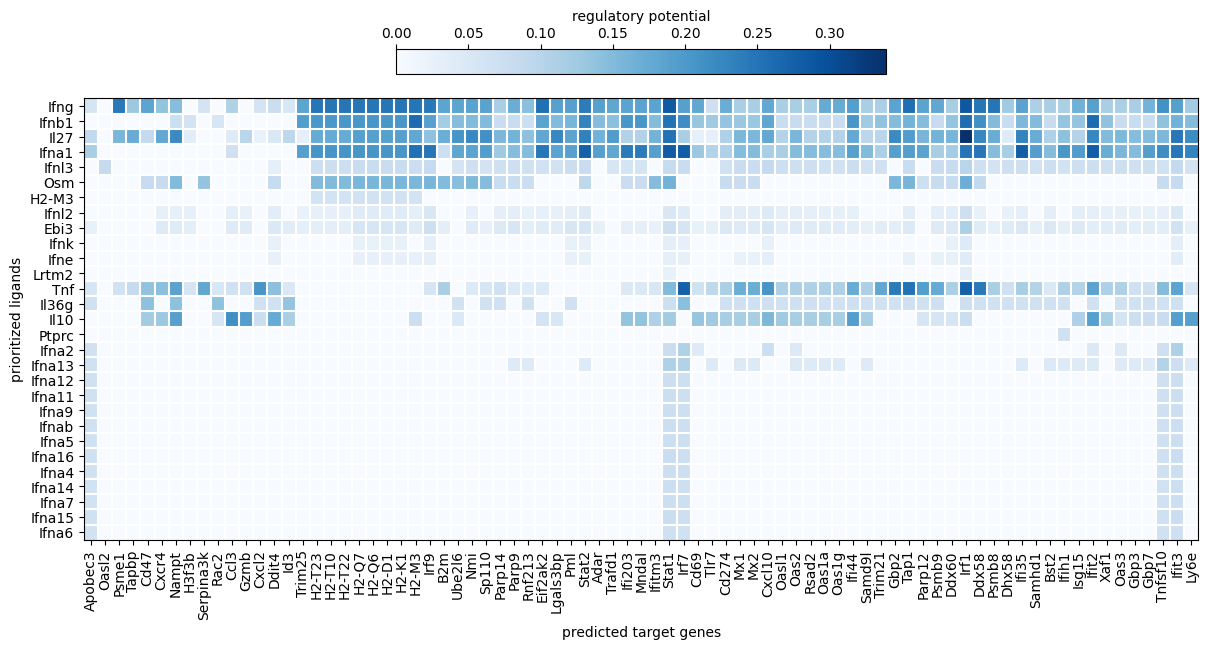

In [22]:
ligand_target_vis, targets, ligands = prepare_ligand_target_visualization(
    predictor,
    active_ligand_target_links,
    cutoff=0.33
)
fig, ax = heatmap_2d(
    ligand_target_vis.transpose(),
    xlabels=targets,
    ylabels=ligands,
    xtitle="predicted target genes",
    ytitle="prioritized ligands",
    cbar_label="regulatory potential",
    cmap="Blues",
    figsize=(12, 6)
)
plt.show()

The rows and columns of the heatmap are ordered based on the rankings of the ligands. We see a lot of interferons in the top ligands, which biologically make sense as we are looking at response to a viral infection.

Note that not all ligands from the top 30 are present in the heatmap. The left-out ligands are ligands that don’t have target genes with high enough regulatory potential scores. Therefore, they did not survive the used cutoffs. To include them, you can be less stringent in the used cutoffs or increase the number of target genes considered. Additionally, if you would consider more than the top 200 targets based on prior information, you will infer more, but less confident, ligand-target links; by considering less than 200 targets, you will be more stringent.

##### Receptors of top-ranked ligands

Similar to above, we identify which receptors have the highest interaction potential with the top-ranked ligands.

In [23]:
lr_sig = WeightedNetwork(filename="D:/Data/nichenetpy/model/mouse/csv/lr_sig_mouse.csv")
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)

Then, we create a heatmap for ligand-receptor interactions. 

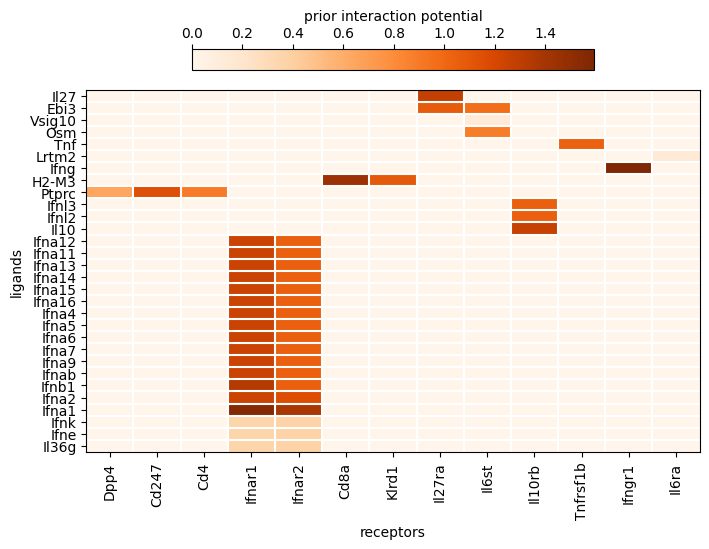

In [24]:
mat, ligands, receptors = prepare_ligand_receptor_visualization(ligand_receptor_links)
fig, ax = heatmap_2d(
    mat,
    xlabels=receptors,
    ylabels=ligands,
    xtitle="receptors",
    ytitle="ligands",
    cbar_label="prior interaction potential",
    cmap="Oranges",
    figsize=(7, 5)
)
plt.show()

#### 6. Sender-focused approach

To perform the sender-focused approach, simply subset the ligand activities to only contain expressed ligands from all populations (calculated in Step 1). We can then perform target gene and receptor inference as above.

In [25]:
ligand_activities_all = ligand_activities.copy()
best_upstream_ligands_all = best_upstream_ligands.copy()
ligand_activities = dict(
    (key, val) for key, val in ligand_activities.items() if key in potential_ligands_focused
)
ligand_activities_sorted = sorted(
    ligand_activities.items(),
    key=lambda x : x[1]["aupr_corrected"],
    reverse=True
)

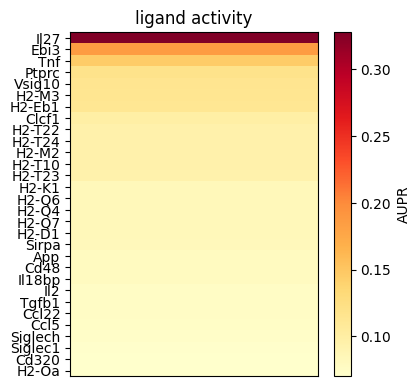

In [26]:
ligands, metrics = zip(*ligand_activities_sorted[:30])
fig, ax = heatmap_1d(
    [e["aupr_corrected"] for e in metrics],
    labels=ligands,
    title="ligand activity",
    cbar_label="AUPR",
    cmap="YlOrRd",
    figsize=(4, 4)
)
ax.invert_yaxis()
plt.show()

In [27]:
best_upstream_ligands = [e[0] for e in ligand_activities_sorted[:30]]
active_ligand_target_links = [
    predictor.get_weighted_ligand_target_links(ligand, geneset, n=100)
    for ligand in best_upstream_ligands
]
active_ligand_target_links = list(
    chain(
        *(zip(cycle([e["ligand"]]), e["target"], e["weight"]) for e in active_ligand_target_links)
    )
)

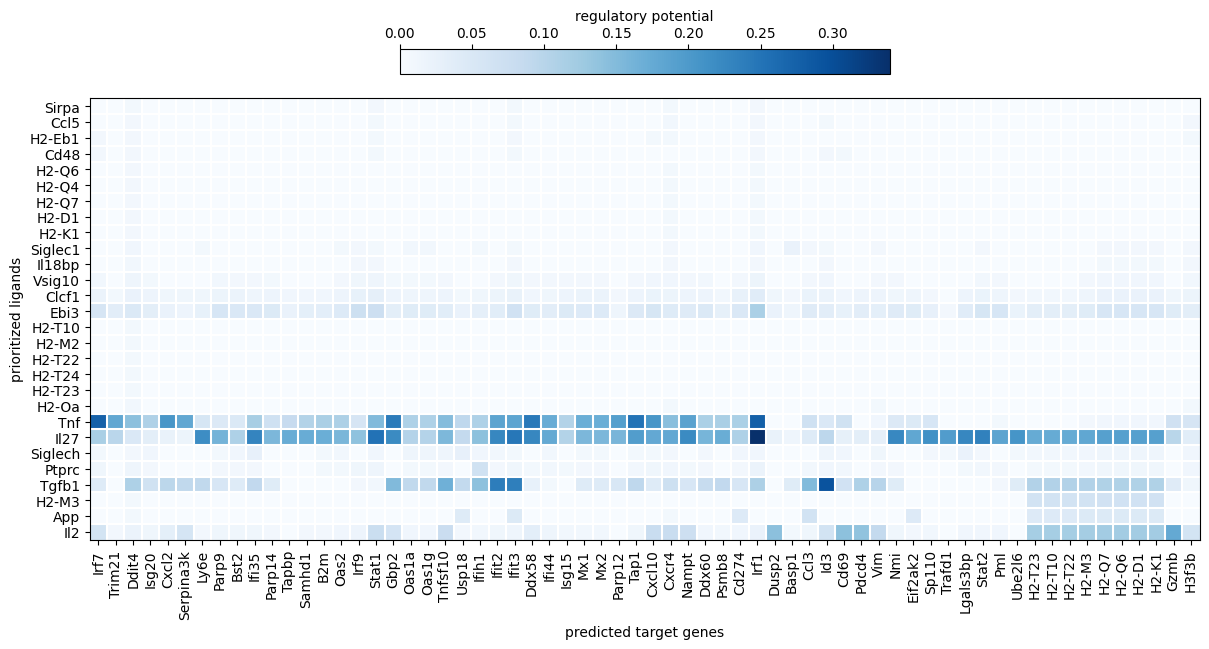

In [28]:
ligand_target_vis, targets, ligands = prepare_ligand_target_visualization(
    predictor,
    active_ligand_target_links,
    cutoff=0.33
)
fig, ax = heatmap_2d(
    ligand_target_vis.transpose(),
    xlabels=targets,
    ylabels=ligands,
    xtitle="predicted target genes",
    ytitle="prioritized ligands",
    cbar_label="regulatory potential",
    cmap="Blues",
    figsize=(12, 6)
)
plt.show()

In [29]:
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)

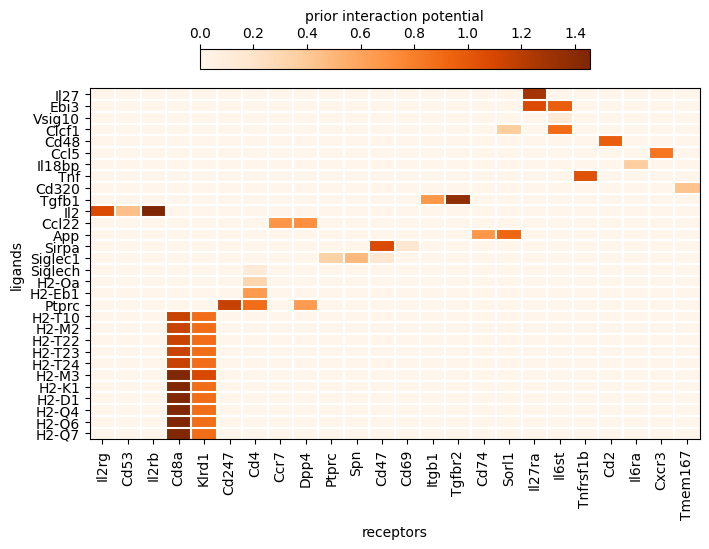

In [30]:
mat, ligands, receptors = prepare_ligand_receptor_visualization(ligand_receptor_links)
fig, ax = heatmap_2d(
    mat,
    xlabels=receptors,
    ylabels=ligands,
    xtitle="receptors",
    ytitle="ligands",
    cbar_label="prior interaction potential",
    cmap="Oranges",
    figsize=(7, 5)
)
plt.show()

Here, we instead observe that the top-ranked ligands consist of many H2 genes (which encode MHC-II proteins), and not IFN genes as in the sender-agnostic approach. This is because IFN genes are not expressed by the sender cell populations, and it was already filtered out during preprocessing for being too lowly expressed.

#### Visualizing expression and log-fold change in sender cells

For the sender-focused approach, we can also investigate further on which sender cell populations are potentially the true sender of these ligands. First, we can simply check which sender cell population expresses which of these top-ranked ligands.

In [31]:
sub_ann = subset_ann(ann, sender_celltypes, layers=["data"])
sub_ann.var = ann.var
sub_ann.X = sub_ann.layers["data"]

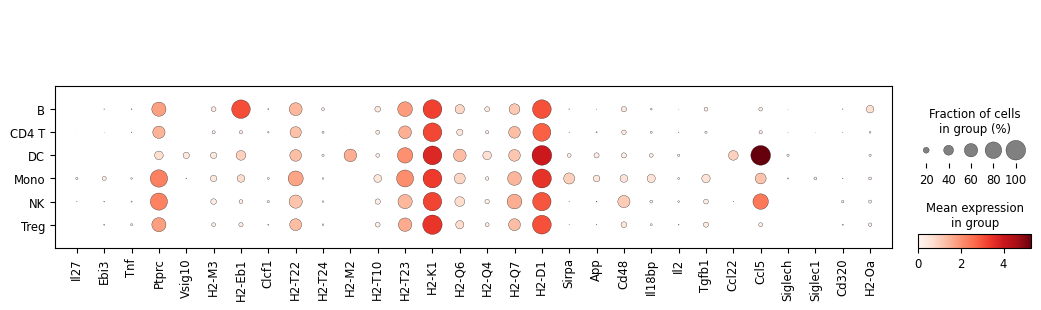

In [32]:
sc.pl.dotplot(
    sub_ann,
    var_names=best_upstream_ligands,
    groupby="celltype",
    gene_symbols="gene"
)

As you can see, most of the top-ranked ligands seem to be mainly expressed by dendritic cells and monocytes.

Next, we can also check upregulation of ligands in sender cells by computing the log-fold change between the two conditions. This ligand differential expression is not used for prioritization and ranking of the ligands (the ranking is only determined based on enrichment of target genes among DE genes in the receiver, CD8T cells), but it can add a useful extra layer of information next to the ligand activities. This is of course only possible in some cases, such as case-control studies.

In [33]:
lfcs = combine_by_key(*(
    get_lfc_celltype(
        ann,
        celltype,
        "aggregate",
        condition_oi="LCMV",
        condition_ref="SS",
        layer="data",
        features=best_upstream_ligands
    )
    for celltype in sender_celltypes
))
# sort by ligand activity
ligands, vals = zip(*(
    (ligand, metrics_vals[1])
    for ligand, metrics_vals in
    sorted(
        combine_dicts(ligand_activities, lfcs).items(),
        key=lambda x : x[1][0]["aupr_corrected"],
        reverse=True
    )
))

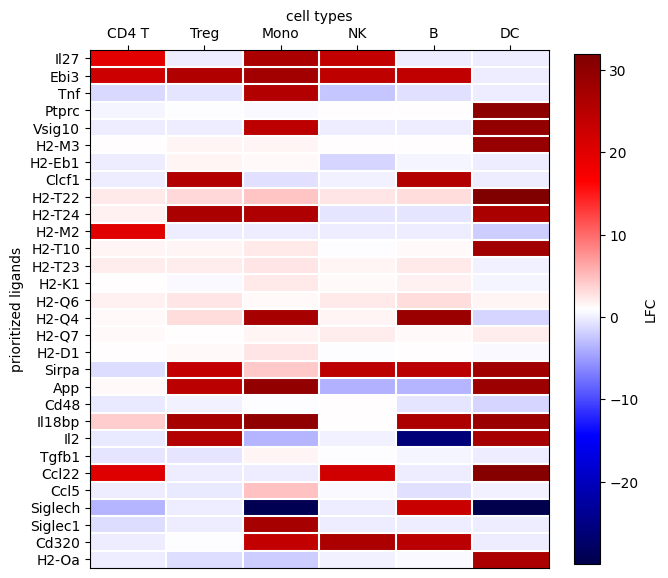

In [34]:
fig, ax = heatmap_2d(
    np.vstack(vals),
    xlabels=sender_celltypes,
    ylabels=ligands,
    xtitle="cell types",
    ytitle="prioritized ligands",
    cbar_label="LFC",
    cbar_position="right",
    cbar_orientation="vertical",
    cmap="seismic",
    figsize=(6, 6)
)
ax.invert_yaxis()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
plt.show()

We see that most of the top-ranked ligands also seem to be upregulated themselves in monocytes after viral infection. This is nice additional “evidence” that these ligands might indeed be important.



Finally, you can also compare rankings between the sender-agnostic and sender-focused approach. Here, the red sections of the left bar plot indicates which ligands in the sender-agnostic approach are filtered out in the sender-focused approach because they are not expressed.

In [35]:
# TODO: custom graph